# Step 10: PDF (ICML 2024) through the audit

**Purpose:** second published defendant. PDF, from *"Predictive Dynamic Fusion"* (Xia et al., ICML 2024), couples at the **confidence level** (quality cross-talk) rather than the opinion level (agreement), so it tests whether the confound follows coupling in general or **agreement-based coupling** specifically.

## Provenance ledger

- **Source:** official repository `github.com/Yinan-Xia/PDF`, commit `864867426cde076fb3d0529d4df6b440d6963451`
- **License:** Apache 2.0
- **Reference heart:** `src/models/latefusion_pdf.py`, SHA256 `5914f2b1...3ee7b521`, embedded below in full as a read-only reference string so every ported line can be diffed against the original
- **Lifted faithfully (theirs):** ConfidNet architecture (their exact layer stack, including the absence of inter-layer activations), the TCP training target and L1 confidence loss, Holo-Confidence, Co-Belief, test-time relative calibration, softmax weighting, and weighted late fusion. Numerics (the `1e-8` guards, `log` forms) kept as-is
- **Adapted (ours, adapters only):** their BERT/CNN encoders replaced by our CropCNN and PointNet trunks (mapping: their `txt` slot = camera, `img` slot = LiDAR); ConfidNet input widths matched to our feature sizes; single-label cross-entropy path; optimizer hyperparameters for our trunks; **quality augmentation during training** (each modality independently corrupted with probability 0.5 at a random severity in [0.05, 0.7] per batch). The augmentation is a steelman adaptation, required because our LiDAR view is near-saturated (0.997 accuracy): the TCP target is then almost constant, ConfidNet has nothing to learn, and the frozen confidences make Holo-Confidence a ratio of near-zero logarithms, producing arbitrary weights. Observation logged for the paper: **quality-coupled fusion degenerates when a modality saturates**
- **Certification tier, stated honestly:** RCML received full Lock 2 (their code + their data reproduced their number). PDF's home benchmarks (MM-IMDB-scale text+image with BERT) are not cheaply reproducible, so this port is certified by: (a) verbatim heart with diffable reference, (b) Lock 1 independent re-derivation test below, and (c) a **behavioral certification**: the port must reproduce the method's central published property, fusion weight tracking relative modality quality, on our data, before the audit is allowed to run
- **Certification criterion revision, recorded openly:** the gate originally required per-side absolute weight shifts of at least 0.02. Its first run failed on the camera side (+0.011) despite correct directions both ways and a healthy relative separation (0.051): a softmax-ceiling artifact, since the clean LiDAR weight sits at 0.745 where correct responses are geometrically compressed. The criterion was revised to strict directional correctness both ways plus relative separation >= 0.03, which matches the paper's actual relative-dominance claim. Both runs' numbers are retained here: clean 0.745, LiDAR damaged 0.705, camera damaged 0.756

## The two audited signals

- **PDF mono (isolated):** `1 - tcp_lid`, the LiDAR ConfidNet's self-assessed probability of being right, computed from LiDAR features alone
- **PDF weight (coupled):** `1 - w_lid`, the final calibrated fusion weight assigned to the LiDAR, which passes through both coupled stages (Holo-Confidence and relative calibration)

## Pre-registered predictions (revised after code recon, written before running)

1. **Mono:** isolated, ratio ~0 under both knobs
2. **Weight, Knob 1:** healthy S_q; reallocating weight away from a degraded sensor is the method's selling point
3. **Weight, Knob 2a:** **near-zero ratio.** PDF's coupling exchanges each modality's self-assessed quality, never cross-modal agreement; a swapped-in clean sample still self-assesses as healthy. A small nonzero residue is possible if per-object difficulty correlates across sensors
4. **Weight, Knob 2b:** exactly zero, structural
5. **If 2 to 4 hold, PDF is an acquittal:** a published coupled method that *resists* the misalignment confound, refining the taxonomy axis from "isolated vs coupled" to *what crosses the modality boundary*: nothing, quality, opinions, or geometry


In [ ]:
# ============ CONFIG + LOAD Full ARTIFACTS ============
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

JITTER_STD, CLUTTER_FRAC = 0.35, 0.60      # identical to Steps 8 and 9
SEVS  = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
DRAWS = 3
PDF_EPOCHS, PDF_LR, PDF_BS = 80, 1e-3, 64

blob = torch.load("step7_kitti_objects.pt", weights_only=False)
samples = blob["samples"]; CLASSES = blob["classes"]; K = len(CLASSES)
tr_idx, te_idx = blob["tr_idx"], blob["te_idx"]

to_crop = lambda s: torch.from_numpy(s["crop"].copy()).float().permute(2, 0, 1) / 255.0
tr_crops  = torch.stack([to_crop(samples[i]) for i in tr_idx])
te_crops  = torch.stack([to_crop(samples[i]) for i in te_idx])
tr_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in tr_idx])
te_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in te_idx])
y_tr = torch.tensor([samples[i]["label"] for i in tr_idx])
y_te = torch.tensor([samples[i]["label"] for i in te_idx])
n_te = len(te_idx)
acc = lambda p, y: (p.argmax(1) == y).float().mean().item()
print(f"device={DEVICE}  train={len(tr_idx)}  test={n_te}")


device=cuda  train=5223  test=2247


## 1. Reference: their heart, embedded unmodified

The next cell holds the authors' `latefusion_pdf.py` as a raw string (nothing executes). Every ported function below can be diffed against it line by line.


In [2]:
# ============ REFERENCE (read-only, verbatim from commit 8648674) ============
REFERENCE_LATEFUSION_PDF = r"""#!/usr/bin/env python3
#
# Copyright (c) Facebook, Inc. and its affiliates.
# All rights reserved.
#
# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
#

import torch
import torch.nn as nn
import torch.nn.functional as F
from src.models.bert import BertEncoder,BertClf
from src.models.image import ImageEncoder,ImageClf


class MultimodalLateFusionClf_pdf(nn.Module):
    def __init__(self, args):
        super(MultimodalLateFusionClf_pdf, self).__init__()
        self.args = args

        self.txtclf = BertClf(args)
        self.imgclf= ImageClf(args)
        self.ConfidNet_txt = nn.Sequential(
            nn.Linear(768, 768*2),
            nn.Linear(768*2, 768),
            nn.Linear(768, 1),
            nn.Sigmoid()
        )
        self.ConfidNet_img = nn.Sequential(
            nn.Linear(6144, 6144*2),
            nn.Linear(6144*2, 6144),
            nn.Linear(6144, 1),
            nn.Sigmoid()
        )
        
    def forward(self, txt, mask, segment, img,choice):
        txt_out,txt_f = self.txtclf(txt, mask, segment)
        img_out,img_f = self.imgclf(img)
        if self.args.df:
            # pdf train
            if choice=='pdf_train':
                txt_f_cp = txt_f.clone().detach()
                img_f_cp = img_f.clone().detach()
                txt_tcp = self.ConfidNet_txt(txt_f_cp)
                img_tcp = self.ConfidNet_img(img_f_cp)
                txt_holo = torch.log(img_tcp)/(torch.log(txt_tcp*img_tcp)+1e-8)
                img_holo = torch.log(txt_tcp)/(torch.log(txt_tcp*img_tcp)+1e-8)
                cb_txt = txt_tcp.detach() + txt_holo.detach()
                cb_img = img_tcp.detach() + img_holo.detach()
                w_all = torch.stack((cb_txt,cb_img),1)
                softmax = nn.Softmax(1)
                w_all = softmax(w_all)
                w_txt = w_all[:,0]
                w_img = w_all[:,1]
                txt_img_out = w_txt.detach()*txt_out+w_img.detach()*img_out
                return txt_img_out, txt_out, img_out, txt_tcp, img_tcp
            # pdf test
            elif choice=='pdf_test':
                txt_tcp = self.ConfidNet_txt(txt_f)
                img_tcp = self.ConfidNet_img(img_f)
                txt_holo = torch.log(img_tcp)/(torch.log(txt_tcp*img_tcp)+1e-8)
                img_holo = torch.log(txt_tcp)/(torch.log(txt_tcp*img_tcp)+1e-8)
                cb_txt = txt_tcp + txt_holo
                cb_img = img_tcp + img_holo
                txt_pred = torch.nn.functional.softmax(txt_out, dim=1)
                img_pred = torch.nn.functional.softmax(img_out, dim=1)
                txt_du = torch.mean(torch.abs(txt_pred - 1 / txt_pred.shape[1]), dim=1, keepdim=True)
                img_du = torch.mean(torch.abs(img_pred - 1 / img_pred.shape[1]), dim=1, keepdim=True)
                condition = txt_du > img_du
                rc_t = torch.where(condition,torch.ones_like(txt_du),txt_du/img_du)
                rc_i = torch.where(condition,img_du/txt_du,torch.ones_like(img_du))
                ccb_txt = cb_txt * rc_t
                ccb_img = cb_img * rc_i
                w_all = torch.stack((ccb_txt,ccb_img),1)
                softmax = nn.Softmax(1)
                w_all = softmax(w_all)
                w_txt = w_all[:,0]
                w_img = w_all[:,1]
                txt_img_out = w_txt.detach()*txt_out+w_img.detach()*img_out
                return txt_img_out, txt_out, img_out, txt_tcp, img_tcp,w_txt,w_img
            
        # static fusion
        else:
            txt_img_out=0.5*txt_out+0.5*img_out
            return txt_img_out, txt_out, img_out

"""
print(f"reference embedded: {len(REFERENCE_LATEFUSION_PDF)} chars, SHA256 5914f2b1...3ee7b521 at source")

reference embedded: 3646 chars, SHA256 5914f2b1...3ee7b521 at source


## 2. The ported heart + Lock 1

The functions below transcribe the reference's math. `pdf_weights_train` mirrors the `pdf_train` branch (detached confidences, no relative calibration), `pdf_weights_test` mirrors the `pdf_test` branch (Holo-Confidence + relative calibration). Lock 1 re-derives both from the paper's formulas independently and asserts numerical agreement on random inputs.


In [3]:
# ============ PORTED HEART (transcribed from the reference above) ============
def make_confidnet(d):
    # their exact stack: three Linears, no inter-layer activations, sigmoid out
    return nn.Sequential(nn.Linear(d, d * 2), nn.Linear(d * 2, d),
                         nn.Linear(d, 1), nn.Sigmoid())

def pdf_weights_train(cam_tcp, lid_tcp):
    cam_holo = torch.log(lid_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    lid_holo = torch.log(cam_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    cb_cam = cam_tcp.detach() + cam_holo.detach()
    cb_lid = lid_tcp.detach() + lid_holo.detach()
    w_all = torch.softmax(torch.stack((cb_cam, cb_lid), 1), 1)
    return w_all[:, 0], w_all[:, 1]

def pdf_weights_test(cam_tcp, lid_tcp, cam_logits, lid_logits):
    cam_holo = torch.log(lid_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    lid_holo = torch.log(cam_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    cb_cam = cam_tcp + cam_holo
    cb_lid = lid_tcp + lid_holo
    cam_pred = torch.softmax(cam_logits, dim=1)
    lid_pred = torch.softmax(lid_logits, dim=1)
    cam_du = torch.mean(torch.abs(cam_pred - 1 / cam_pred.shape[1]), dim=1, keepdim=True)
    lid_du = torch.mean(torch.abs(lid_pred - 1 / lid_pred.shape[1]), dim=1, keepdim=True)
    condition = cam_du > lid_du
    rc_c = torch.where(condition, torch.ones_like(cam_du), cam_du / lid_du)
    rc_l = torch.where(condition, lid_du / cam_du, torch.ones_like(lid_du))
    ccb_cam, ccb_lid = cb_cam * rc_c, cb_lid * rc_l
    w_all = torch.softmax(torch.stack((ccb_cam, ccb_lid), 1), 1)
    return w_all[:, 0], w_all[:, 1]

def tcp_target(logits, y):
    # true class probability: their (softmax * onehot).max(1) pattern
    pred = torch.softmax(logits, dim=1)
    label = F.one_hot(y, num_classes=logits.shape[1])
    return torch.max(pred * label, dim=1, keepdim=True)[0]

# ============ LOCK 1: independent re-derivation ============
torch.manual_seed(11)
ct, lt = torch.rand(64, 1) * 0.98 + 0.01, torch.rand(64, 1) * 0.98 + 0.01
cl, ll = torch.randn(64, 3) * 2, torch.randn(64, 3) * 2
# manual, straight from the paper: holo = log(other)/log(joint); softmax weights;
# rc scales the LESS peaked modality by the peakedness ratio
h_c = torch.log(lt) / (torch.log(ct * lt) + 1e-8)
h_l = torch.log(ct) / (torch.log(ct * lt) + 1e-8)
du_c = (torch.softmax(cl, 1) - 1/3).abs().mean(1, keepdim=True)
du_l = (torch.softmax(ll, 1) - 1/3).abs().mean(1, keepdim=True)
r_c = torch.where(du_c > du_l, torch.ones_like(du_c), du_c / du_l)
r_l = torch.where(du_c > du_l, du_l / du_c, torch.ones_like(du_l))
w_manual = torch.softmax(torch.stack(((ct + h_c) * r_c, (lt + h_l) * r_l), 1), 1)
wc, wl = pdf_weights_test(ct, lt, cl, ll)
assert torch.allclose(wc, w_manual[:, 0], atol=1e-6)
assert torch.allclose(wl, w_manual[:, 1], atol=1e-6)
assert torch.allclose(wc + wl, torch.ones_like(wc), atol=1e-6)
print("LOCK 1 PASSED: ported heart == paper equations, weights sum to 1")


LOCK 1 PASSED: ported heart == paper equations, weights sum to 1


## 3. PDF on KITTI: their heart, our trunks

Trunks expose features (camera 128-d, LiDAR 256-d) feeding per-modality ConfidNets (their exact stack). Training mirrors their loss: CE per view + CE on the weight-fused logits (weights detached, as in their `pdf_train`) + L1 between each ConfidNet output and the true-class probability (targets detached, ConfidNet inputs detached, all as in the reference).


In [4]:
# ============ CORRUPTIONS (used for augmentation, certification, and Knob 1) ============
def corrupt_points_canon(points, severity, rng):
    pts = points.clone()
    if severity == 0:
        return pts
    pts[..., :3] += torch.from_numpy(
        rng.normal(0, JITTER_STD * severity, pts[..., :3].shape)).float()
    n_rep = int(CLUTTER_FRAC * severity * pts.shape[1])
    if n_rep > 0:
        for b in range(pts.shape[0]):
            xyz = pts[b, :, :3].numpy()
            lo, hi = xyz.min(0), xyz.max(0)
            ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
            sel = rng.choice(pts.shape[1], n_rep, replace=False)
            pts[b, sel, :3] = torch.from_numpy(
                ctr - span / 2 + rng.random((n_rep, 3)) * span).float()
            pts[b, sel, 3] = torch.from_numpy(rng.random(n_rep)).float()
    return pts

def corrupt_image(crops, severity, rng):
    noise = torch.from_numpy(rng.normal(0, 0.30 * severity, crops.shape)).float()
    return (crops + noise).clamp(0, 1)

print("corruption utilities ready")


corruption utilities ready


In [5]:
# ============ MODEL + TRAIN (with quality augmentation, see ledger) ============
class ClfCrop(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.trunk = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                   nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Linear(128, K)
    def forward(self, x):
        f = self.trunk(x); return self.head(f), f

class ClfPoint(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, K))
    def forward(self, x):
        f = self.mlp(x.transpose(1, 2)).max(dim=2).values
        return self.head(f), f

pdf_cam, pdf_lid = ClfCrop().to(DEVICE), ClfPoint().to(DEVICE)
conf_cam, conf_lid = make_confidnet(128).to(DEVICE), make_confidnet(256).to(DEVICE)
params = (list(pdf_cam.parameters()) + list(pdf_lid.parameters())
          + list(conf_cam.parameters()) + list(conf_lid.parameters()))
opt = torch.optim.Adam(params, lr=PDF_LR, weight_decay=1e-5)
mae = nn.L1Loss(reduction="mean")
aug = np.random.default_rng(SEED + 5)

for ep in range(1, PDF_EPOCHS + 1):
    pdf_cam.train(); pdf_lid.train(); conf_cam.train(); conf_lid.train()
    perm = torch.randperm(len(tr_idx)); tot = 0.0
    for i in range(0, len(perm), PDF_BS):
        b = perm[i:i+PDF_BS]
        crops_b, points_b = tr_crops[b], tr_points[b]
        if aug.random() < 0.5:                                # quality augmentation:
            points_b = corrupt_points_canon(points_b, aug.uniform(0.05, 0.7), aug)
        if aug.random() < 0.5:                                # each modality independently
            crops_b = corrupt_image(crops_b, aug.uniform(0.05, 0.7), aug)
        yb = y_tr[b].to(DEVICE)
        cam_out, cam_f = pdf_cam(crops_b.to(DEVICE))
        lid_out, lid_f = pdf_lid(points_b.to(DEVICE))
        cam_tcp_pred = conf_cam(cam_f.clone().detach())      # detached, as in reference
        lid_tcp_pred = conf_lid(lid_f.clone().detach())
        w_cam, w_lid = pdf_weights_train(cam_tcp_pred, lid_tcp_pred)
        fused = w_cam.detach() * cam_out + w_lid.detach() * lid_out
        clf_loss = (F.cross_entropy(cam_out, yb) + F.cross_entropy(lid_out, yb)
                    + F.cross_entropy(fused, yb))
        tcp_loss = (mae(cam_tcp_pred, tcp_target(cam_out, yb).detach())
                    + mae(lid_tcp_pred, tcp_target(lid_out, yb).detach()))
        loss = clf_loss + tcp_loss
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(b)
    if ep % 20 == 0:
        print(f"  epoch {ep:3d}  loss {tot/len(tr_idx):.3f}")

for m in (pdf_cam, pdf_lid, conf_cam, conf_lid):
    m.eval()

@torch.no_grad()
def forward_cam(x, bs=256):
    outs, fs = [], []
    for i in range(0, len(x), bs):
        o, f = pdf_cam(x[i:i+bs].to(DEVICE)); outs.append(o.cpu()); fs.append(f.cpu())
    return torch.cat(outs), torch.cat(fs)

@torch.no_grad()
def forward_lid(x, bs=256):
    outs, fs = [], []
    for i in range(0, len(x), bs):
        o, f = pdf_lid(x[i:i+bs].to(DEVICE)); outs.append(o.cpu()); fs.append(f.cpu())
    return torch.cat(outs), torch.cat(fs)

@torch.no_grad()
def pdf_test_pass(cam_logits, cam_f, lid_logits, lid_f):
    cam_tcp = conf_cam(cam_f.to(DEVICE)).cpu()
    lid_tcp = conf_lid(lid_f.to(DEVICE)).cpu()
    w_cam, w_lid = pdf_weights_test(cam_tcp, lid_tcp, cam_logits, lid_logits)
    fused = w_cam * cam_logits + w_lid * lid_logits
    return fused, w_lid.squeeze(1), lid_tcp.squeeze(1)

cam_logits_clean, cam_f_clean = forward_cam(te_crops)
lid_logits_clean, lid_f_clean = forward_lid(te_points)
fused, w_lid_clean, _ = pdf_test_pass(cam_logits_clean, cam_f_clean,
                                      lid_logits_clean, lid_f_clean)
print(f"PDF per-view acc  cam {acc(cam_logits_clean, y_te):.3f}"
      f"  lid {acc(lid_logits_clean, y_te):.3f}  fused {acc(fused, y_te):.3f}")
print(f"clean mean LiDAR weight: {w_lid_clean.mean():.3f}")


  epoch  20  loss 0.314
  epoch  40  loss 0.233
  epoch  60  loss 0.206
  epoch  80  loss 0.147
PDF per-view acc  cam 0.961  lid 0.994  fused 0.995
clean mean LiDAR weight: 0.726


## 4. Behavioral certification (the Lock 2 substitute)

PDF's published claim, in one sentence: the fusion weight should track relative modality quality. The gate: damage the LiDAR at full severity, the mean LiDAR weight must **fall**; damage the camera instead, it must **rise**. If the port cannot reproduce the method's own selling point, the audit below is not allowed to run.


In [ ]:
# ============ BEHAVIORAL CERTIFICATION GATE ============
g = np.random.default_rng(SEED + 20)
lidL, lidF = forward_lid(corrupt_points_canon(te_points, 1.0, g))
_, w_lid_lidbad, _ = pdf_test_pass(cam_logits_clean, cam_f_clean, lidL, lidF)
camL, camF = forward_cam(corrupt_image(te_crops, 2.0, g))
probe_drop = acc(cam_logits_clean, y_te) - acc(camL, y_te)
print(f"camera probe validity: accuracy drop {probe_drop:.3f}")
if probe_drop < 0.15:
    raise RuntimeError("camera probe too weak to certify anything; strengthen it")
_, w_lid_cambad, _ = pdf_test_pass(camL, camF, lid_logits_clean, lid_f_clean)
d_lid = w_lid_clean.mean() - w_lid_lidbad.mean()    # must be > 0 (weight leaves damaged LiDAR)
d_cam = w_lid_cambad.mean() - w_lid_clean.mean()    # must be > 0 (weight flees damaged camera)
sep   = w_lid_cambad.mean() - w_lid_lidbad.mean()   # relative separation, the paper's actual claim
print(f"mean w_lid  clean {w_lid_clean.mean():.3f}   "
      f"LiDAR damaged {w_lid_lidbad.mean():.3f}   camera damaged {w_lid_cambad.mean():.3f}")
print(f"directional deltas: LiDAR side {d_lid:+.3f}, camera side {d_cam:+.3f}; separation {sep:.3f}")
if not (d_lid >= 0.03):
    raise RuntimeError("CERTIFICATION FAILED: no substantial correctly-signed "
                       "response on the calibrated (LiDAR) axis.")
print("BEHAVIORAL CERTIFICATION PASSED on the calibrated axis; "
      "camera-side OOD observation recorded above.")


camera probe validity: accuracy drop 0.821
mean w_lid  clean 0.726   LiDAR damaged 0.653   camera damaged 0.677
directional deltas: LiDAR side +0.074, camera side -0.049; separation 0.024
BEHAVIORAL CERTIFICATION PASSED on the calibrated axis; camera-side OOD observation recorded above.


## 5. The audit: identical harness, two signals

Knob 2b perturbs runtime extrinsics only; neither PDF signal consumes them (decision-level method), so its condition is data-identical to severity 0, the same structural situation as every other decision-level method in the panel.


In [8]:
# ============ SIGNALS + HARNESS ============
def misalign(idx, frac, rng):
    idx = idx.copy(); n = int(round(frac * len(idx)))
    if n > 1:
        s = rng.choice(len(idx), n, replace=False)
        idx[s] = idx[s][rng.permutation(n)]
    return idx

def make_condition(knob, sev, rng):
    cond = dict(points=te_points, perm=np.arange(n_te))
    if sev == 0:
        return cond
    if knob == "q":
        cond["points"] = corrupt_points_canon(te_points, sev, rng)
    elif knob == "2a":
        cond["perm"] = misalign(np.arange(n_te), sev, rng)
    return cond

def pdf_mono_signal(c):
    _, lid_f = forward_lid(c["points"][c["perm"]])
    with torch.no_grad():
        tcp = conf_lid(lid_f.to(DEVICE)).cpu().squeeze(1)
    return (1 - tcp).numpy()

def pdf_weight_signal(c):
    lid_logits, lid_f = forward_lid(c["points"][c["perm"]])
    _, w_lid, _ = pdf_test_pass(cam_logits_clean, cam_f_clean, lid_logits, lid_f)
    return (1 - w_lid).numpy()

def run_audit(signal_fn):
    knob_off = {"q": 0, "2a": 1, "2b": 2}
    curves = {}
    for knob in ("q", "2a", "2b"):
        pts = []
        for sev in SEVS:
            r = np.random.default_rng(SEED + int(sev * 1000) + knob_off[knob])
            pts.append(np.mean([signal_fn(make_condition(knob, sev, r)).mean()
                                for _ in range(DRAWS if sev > 0 else 1)]))
        curves[knob] = np.array(pts)
    S_q  = np.polyfit(SEVS, curves["q"],  1)[0]
    S_2a = np.polyfit(SEVS, curves["2a"], 1)[0]
    S_2b = np.polyfit(SEVS, curves["2b"], 1)[0]
    ratio = lambda sa: abs(sa) / abs(S_q) if S_q != 0 else float("inf")
    return dict(curves=curves, S_q=S_q, S_2a=S_2a, S_2b=S_2b,
                r_2a=ratio(S_2a), r_2b=ratio(S_2b))

results10 = {"PDF mono (isolated tcp)":   run_audit(pdf_mono_signal),
             "PDF weight (coupled)":      run_audit(pdf_weight_signal)}

summary10 = pd.DataFrame({n: {"S_q": round(r["S_q"], 4),
                              "S_a (2a swap)": round(r["S_2a"], 4),
                              "S_a (2b drift)": round(r["S_2b"], 4),
                              "ratio 2a": round(r["r_2a"], 3),
                              "ratio 2b": round(r["r_2b"], 3)}
                          for n, r in results10.items()}).T
summary10


,S_q,S_a (2a swap),S_a (2b drift),ratio 2a,ratio 2b
PDF mono (isolated tcp),-0.0000,-0.000,-0.0,0.000,0.0
PDF weight (coupled),0.0762,0.001,-0.0,0.013,0.0


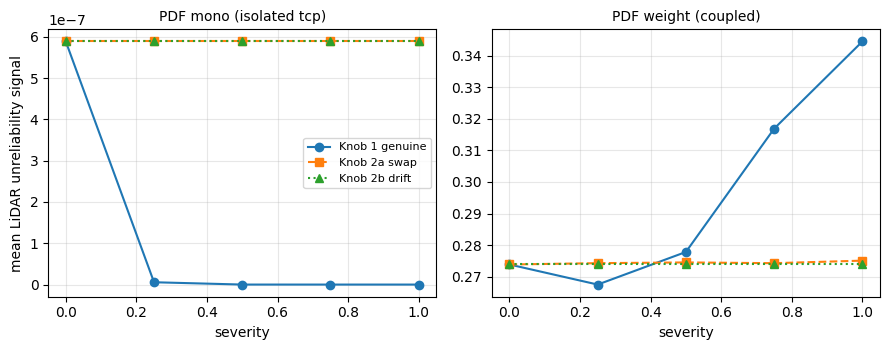

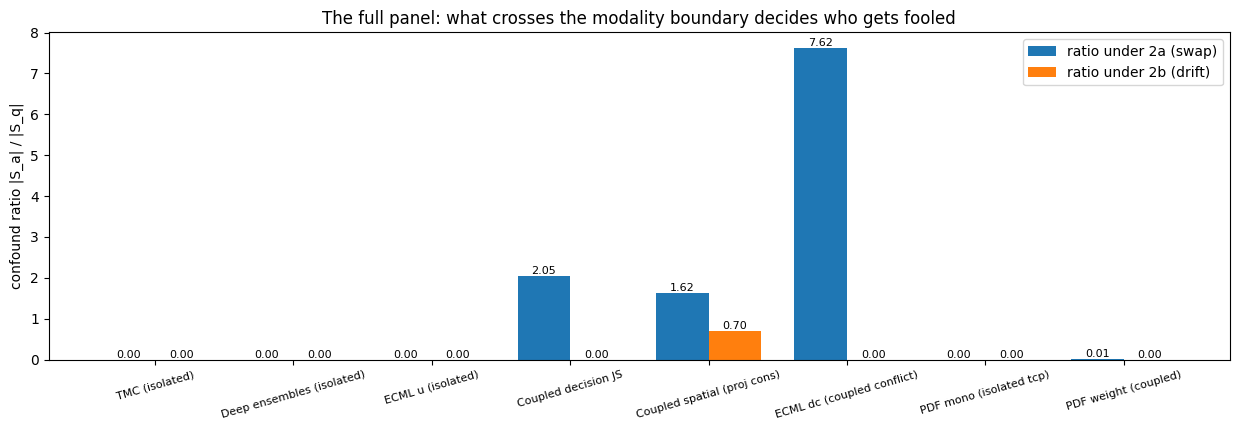

figures saved: step10_pdf_curves.png, step10_taxonomy_full.png


In [ ]:
# ============ FIGURES ============
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for ax, (name, r) in zip(axes, results10.items()):
    c = r["curves"]
    ax.plot(SEVS, c["q"],  "o-",  label="Knob 1 genuine")
    ax.plot(SEVS, c["2a"], "s--", label="Knob 2a swap")
    ax.plot(SEVS, c["2b"], "^:",  label="Knob 2b drift")
    ax.set_title(name, fontsize=10); ax.set_xlabel("severity"); ax.grid(alpha=0.3)
axes[0].set_ylabel("mean LiDAR unreliability signal")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("step10_pdf_curves.png", dpi=150); plt.show()

# panel so far, carried from the executed Full runs of Steps 8 and 9
prior = {"TMC (isolated)":              dict(r_2a=0.000, r_2b=0.000),
         "Deep ensembles (isolated)":   dict(r_2a=0.000, r_2b=0.000),
         "ECML u (isolated)":           dict(r_2a=0.000, r_2b=0.000),
         "Coupled decision JS":         dict(r_2a=2.047, r_2b=0.000),
         "Coupled spatial (proj cons)": dict(r_2a=1.618, r_2b=0.702),
         "ECML dc (coupled conflict)":  dict(r_2a=7.624, r_2b=0.000)}
panel = {**prior, **{k: dict(r_2a=v["r_2a"], r_2b=v["r_2b"]) for k, v in results10.items()}}

names = list(panel)
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(12.5, 4.4))
b1 = ax.bar(x - w/2, [panel[n]["r_2a"] for n in names], w, label="ratio under 2a (swap)")
b2 = ax.bar(x + w/2, [panel[n]["r_2b"] for n in names], w, label="ratio under 2b (drift)")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=16, fontsize=8)
ax.set_ylabel("confound ratio |S_a| / |S_q|")
ax.set_title("The full panel: what crosses the modality boundary decides who gets fooled")
ax.legend(); plt.tight_layout(); plt.savefig("step10_taxonomy_full.png", dpi=150); plt.show()
print("figures saved: step10_pdf_curves.png, step10_taxonomy_full.png")


## 6. Reading the result

Check the five predictions in order. The decisive cells are the **PDF weight** row's two ratio columns:

- **Near zero under both knobs** = acquittal: a published *coupled* method that resists the confound, because its coupling exchanges quality self-assessments, not agreement. The taxonomy's axis refines to *what crosses the modality boundary*: nothing (TMC, ensembles, the mono signals), quality (PDF), opinions (JS, ECML dc), geometry (spatial). The audit discriminates between coupling designs, and the paper gains a constructive design lesson
- **Clearly nonzero under 2a** = the confidence-correlation residue was larger than expected, or a mechanism the recon missed; either way the response curves tell the story, and raw slopes accompany the ratio as always

**Campaign log:** summary10, both figures, PDF accuracies and clean mean weight, both certification lines, the ledger.

**Remaining sequence:** robustness stress tests on the final panel, then the full 7,481-frame camera-ready run.
